In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [ ]:
from torch import nn

# **MODEL_01**

Creating  random tensors

In [ ]:
weight =0.9
bias =0.7

start =0
end=1
step=0.02

X=torch.arange(start,end,step).unsqueeze(dim=1)
Y=weight*X+bias


In [ ]:
X[:10],Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.7000],
         [0.7180],
         [0.7360],
         [0.7540],
         [0.7720],
         [0.7900],
         [0.8080],
         [0.8260],
         [0.8440],
         [0.8620]]))

Data split into train and test data

In [ ]:
train_split=int(0.8*len(X))

In [ ]:
x_train,y_train=X[:train_split],Y[:train_split]
x_test,y_test=X[train_split:],Y[train_split:]

Plot function

In [ ]:
def plot_prediction(train_data=x_train,
                    train_lable=y_train,
                    test_data=x_test,
                    test_lable=y_test,
                    prediction=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_lable,c="b",s=4,label="training data")
  plt.scatter(test_data,test_lable,c="r",s=4,label="testing data")
  if prediction is not None:
    plt.scatter(test_data,prediction,c="g",s=4,label="prediction")

  plt.legend(prop={"size":14});


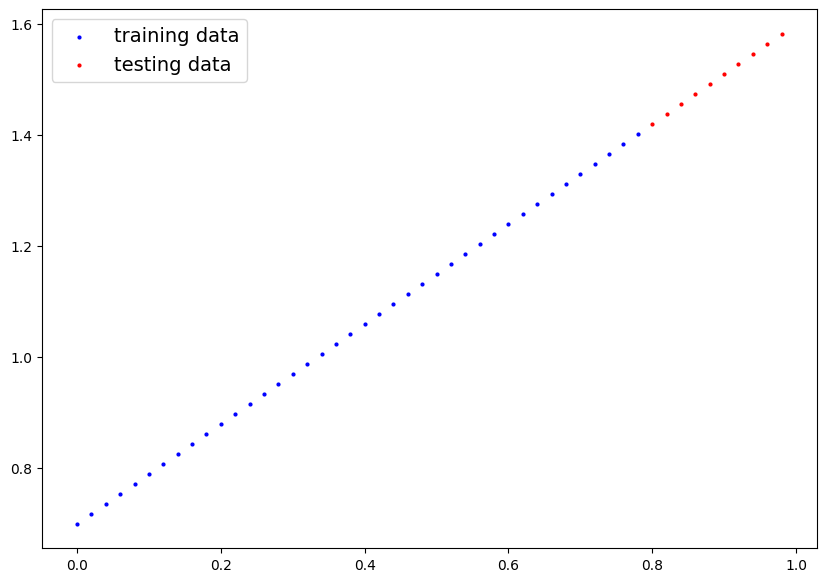

In [ ]:
plot_prediction()

We are going to make a custom model to get weight and biases

In [ ]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
    self.bias =nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)

  def forward(self,x :torch.Tensor)->torch.Tensor:
    return self.weights*x+self.bias

In [ ]:
torch.manual_seed(42)
model_0=LinearRegressionModel()

In [ ]:
with torch.inference_mode():
  y_preds=model_0(x_test)


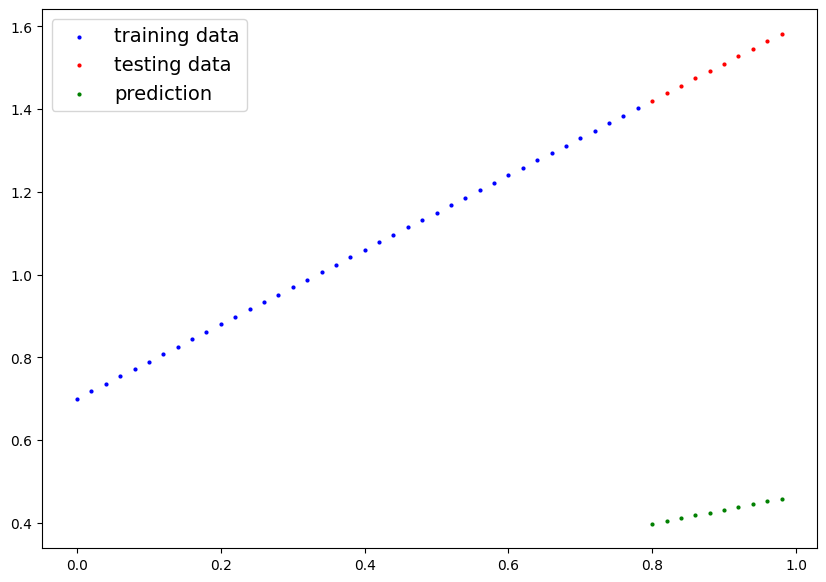

In [ ]:
plot_prediction(prediction=y_preds)

In [ ]:
loss_fn=torch.nn.L1Loss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [ ]:
torch.manual_seed(42)
epochs=168
train_loss_values=[]
test_loss_values=[]
epoch_count = []

for epoch in range(epochs):

  model_0.train()
  y_pred=model_0(x_train)
  loss=loss_fn(y_pred,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model_0.eval()

  with torch.inference_mode():
    test_pred=model_0(x_test)
    test_loss=loss_fn(test_pred,y_test.type(torch.float))

    if epoch % 10 ==0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f"Epoch:{epoch} | Train loss:{loss} | test loss:{test_loss}")


Epoch:0 | Train loss:0.790881335735321 | test loss:1.0590652227401733
Epoch:10 | Train loss:0.6756712794303894 | test loss:0.924355149269104
Epoch:20 | Train loss:0.5604613423347473 | test loss:0.7896453142166138
Epoch:30 | Train loss:0.4452515244483948 | test loss:0.6549354195594788
Epoch:40 | Train loss:0.3300415873527527 | test loss:0.5202255845069885
Epoch:50 | Train loss:0.21483173966407776 | test loss:0.3855157792568207
Epoch:60 | Train loss:0.10542317479848862 | test loss:0.2553948760032654
Epoch:70 | Train loss:0.06415165215730667 | test loss:0.1767505556344986
Epoch:80 | Train loss:0.05387822538614273 | test loss:0.13857345283031464
Epoch:90 | Train loss:0.04955670237541199 | test loss:0.11944428831338882
Epoch:100 | Train loss:0.04606669023633003 | test loss:0.10842454433441162
Epoch:110 | Train loss:0.04260227456688881 | test loss:0.09877844899892807
Epoch:120 | Train loss:0.039163462817668915 | test loss:0.09050609171390533
Epoch:130 | Train loss:0.03573359549045563 | test 

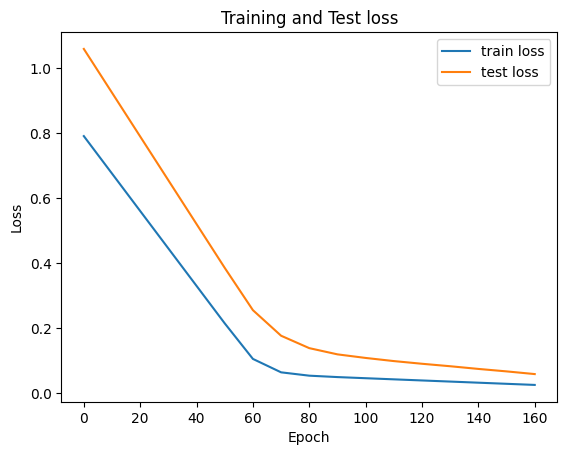

In [ ]:
plt.plot(epoch_count,train_loss_values,label="train loss")
plt.plot(epoch_count,test_loss_values,label="test loss")
plt.title("Training and Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.7871])), ('bias', tensor([0.7473]))])

In [ ]:
with torch.inference_mode():
  y_preds=model_0(x_test)

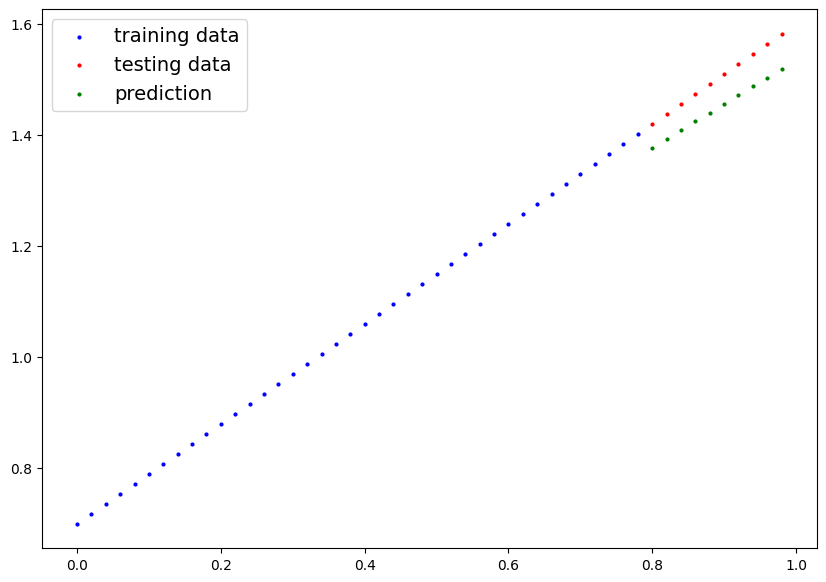

In [ ]:
plot_prediction(prediction=y_preds)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.7871])), ('bias', tensor([0.7473]))])

Saving model data and state_dict

In [ ]:
from pathlib import Path

MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

MODEL_NAME="model_01_pytorch.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME
print(MODEL_SAVE_PATH)
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

models/model_01_pytorch.pth


# **MODEL_02**

Random Tensor block

In [ ]:
weight_02=0.5
bias_02=0.3

start=0
end=10
gap=0.1
X_sample_tensor_02=torch.arange(start,end,gap).unsqueeze(dim=1)
Y_sample_tensor_02=weight_02*X_sample_tensor_02+bias_02


In [ ]:
X_sample_tensor_02[:10],Y_sample_tensor_02[:10]

(tensor([[0.0000],
         [0.1000],
         [0.2000],
         [0.3000],
         [0.4000],
         [0.5000],
         [0.6000],
         [0.7000],
         [0.8000],
         [0.9000]]),
 tensor([[0.3000],
         [0.3500],
         [0.4000],
         [0.4500],
         [0.5000],
         [0.5500],
         [0.6000],
         [0.6500],
         [0.7000],
         [0.7500]]))

Data split block

In [ ]:
split_margin=int(0.8*len(X_sample_tensor_02))


In [ ]:
x_train02,x_test02=X_sample_tensor_02[:split_margin],X_sample_tensor_02[split_margin:]
y_train02,y_test02=Y_sample_tensor_02[:split_margin],Y_sample_tensor_02[split_margin:]

Prediction fuction block

In [ ]:
def plot_prediction02(train_data=x_test02,
                      train_label=y_train02,
                      test_data=x_test02,
                      test_label=y_test02,
                      prediction=None
                      ):
  plt.figure(figsize=(10,7))
  plt.scatter(x_train02,y_train02,c="b",s=4,label="training data")
  plt.scatter(x_test02,y_test02,c="r",s=4,label="test data")

  if prediction is not None:
    plt.scatter(test_data,prediction,c="g",s=4,label="prediction")
  plt.legend(prop={"size":14});

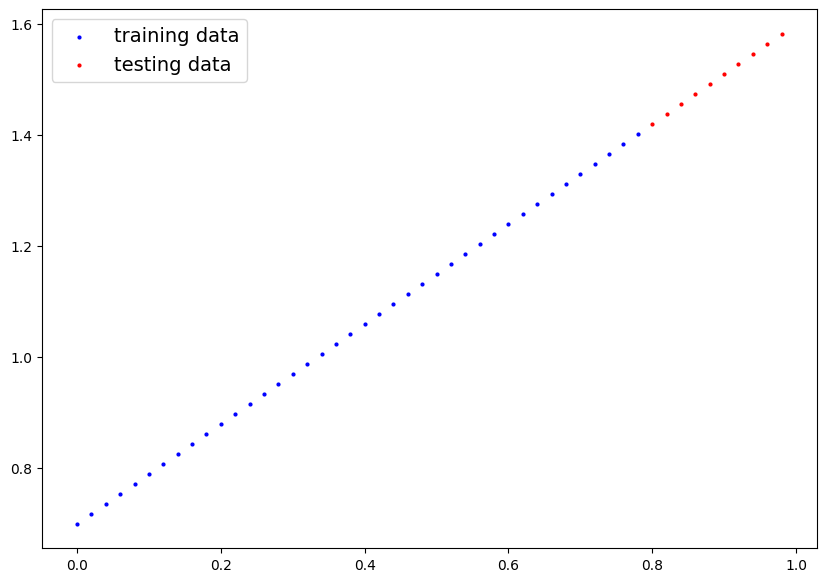

In [ ]:
plot_prediction()

model decleration block

In [ ]:
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1,out_features=1)
  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.linear_layer(x)


In [ ]:
torch.manual_seed(42)
model_v2=LinearRegressionModelV2()

Loss fuction declaration block

In [ ]:
loss_fn_02=nn.L1Loss()
optimizer_02=torch.optim.SGD(params=model_v2.parameters(),
                             lr=0.01)

Device declaration block

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
next(model_v2.parameters()).device

device(type='cpu')

In [ ]:
model_v2.to(device)
next(model_v2.parameters()).device

device(type='cpu')

Training loop Block

In [ ]:
torch.manual_seed(42)
epoches=150;

for epoch in range (epoches):
  model_v2.train()
  y_pred_v2=model_v2(x_train02)
  loss_v2=loss_fn_02(y_pred_v2,y_train02)
  optimizer_02.zero_grad()
  loss_v2.backward()
  optimizer_02.step()


model set to evaluation mode

In [ ]:
model_v2.eval()

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

Prediction block

In [ ]:
with torch.inference_mode():
  test_pred_02=model_v2(x_test02)



Prediction visualization block

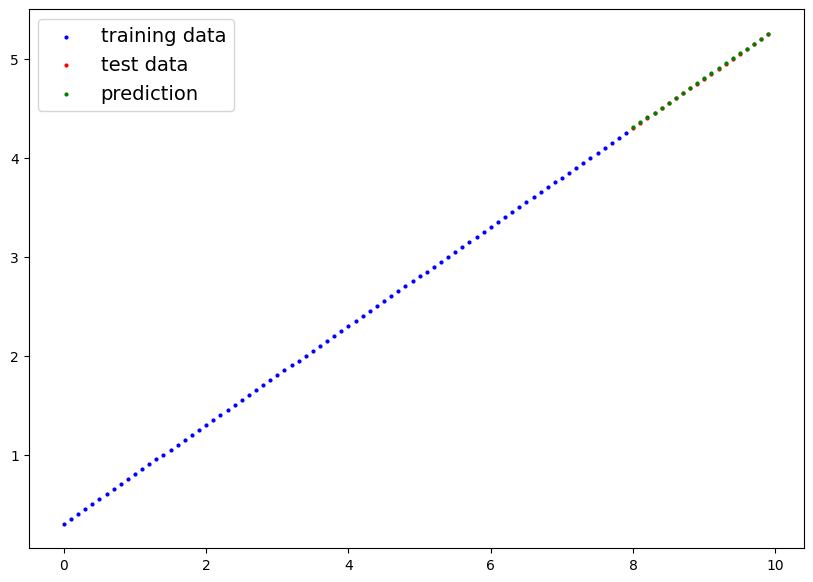

In [ ]:
plot_prediction02(prediction=test_pred_02)

In [ ]:
from pathlib import Path
MODEL_PATH_02=MODEL_PATH
MODEL_NAME_02="model_02_pytorch.pth"
MODEL_SAVE_PATH_02=MODEL_PATH_02/MODEL_NAME_02
torch.save(obj=model_v2.state_dict(),
           f=MODEL_SAVE_PATH_02)